##**This project aims to predict the Brazil's GDP for the next Ten Years**

The first step was finding the most appropriate data. I found it from the World Bank

In [1]:
# To show the time necessary to run all code
import time
start_time = time.time()

In [2]:
# Upload the file from DataBank - WorldBank
import pandas as pd
import numpy as np
url = 'https://raw.github.com/Heitor-vn/Data-Mining---UDC/main/GDP_Databank.csv'
# Upload the file, and replace the '..' for Nan values
data = pd.read_csv('https://raw.github.com/Heitor-vn/Data-Mining---UDC/main/GDP_Databank.csv')
# Transpose the table
Data = data.T
# Show how many information it have:
print(f"The transposed data has {Data.shape[0]} rows and {Data.shape[1]} columns.")

# Check for missing values
Data.isnull().sum()

The transposed data has 69 rows and 1521 columns.


,0
0,0
1,0
2,0
3,0
4,0
...,...
1516,69
1517,69
1518,69
1519,68


I found that exists missing values in the data. But in the original data, there is many values showed like this '..', I will replace this values by NaN too

In [3]:
# Add this previous step, so I can work with the data below - Converts every '..' to NaN
Data = Data.replace('..', np.nan)
Data.head()

/tmp/ipython-input-3-356994321.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Data = Data.replace('..', np.nan)


,0,1,2,3,4,5,6,7,8,9,...,1511,1512,1513,1514,1515,1516,1517,1518,1519,1520
Country Name,Brazil,Brazil,Brazil,Brazil,Brazil,Brazil,Brazil,Brazil,Brazil,Brazil,...,Brazil,Brazil,Brazil,Brazil,Brazil,NaN,NaN,NaN,Data from database: World Development Indicators,Last Updated: 07/01/2025
Country Code,BRA,BRA,BRA,BRA,BRA,BRA,BRA,BRA,BRA,BRA,...,BRA,BRA,BRA,BRA,BRA,NaN,NaN,NaN,NaN,NaN
Series Name,"Adolescent fertility rate (births per 1,000 wo...","Agriculture, forestry, and fishing, value adde...","Annual freshwater withdrawals, total (% of int...",Births attended by skilled health staff (% of ...,"Contraceptive prevalence, any method (% of mar...",Domestic credit provided by financial sector (...,Electric power consumption (kWh per capita),Energy use (kg of oil equivalent per capita),Exports of goods and services (% of GDP),"External debt stocks, total (DOD, current US$)",...,Women who believe a husband is justified in be...,Women who were first married by age 15 (% of w...,Women who were first married by age 18 (% of w...,Women's share of population ages 15+ living wi...,Young people (ages 15-24) newly infected with HIV,NaN,NaN,NaN,NaN,NaN
Series Code,SP.ADO.TFRT,NV.AGR.TOTL.ZS,ER.H2O.FWTL.ZS,SH.STA.BRTC.ZS,SP.DYN.CONU.ZS,FS.AST.DOMS.GD.ZS,EG.USE.ELEC.KH.PC,EG.USE.PCAP.KG.OE,NE.EXP.GNFS.ZS,DT.DOD.DECT.CD,...,SG.VAW.REFU.ZS,SP.M15.2024.FE.ZS,SP.M18.2024.FE.ZS,SH.DYN.AIDS.FE.ZS,SH.HIV.INCD.YG,NaN,NaN,NaN,NaN,NaN
1960 [YR1960],91.302,0,NaN,NaN,NaN,NaN,NaN,NaN,6.28181356216762,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The next step, I made after some steps, so I need to return and do that in order to optimze the code in forward steps. I put aside the titles of the columns together with more three lines from header, making a total of 4 rows. Leaving now only the years and the respectives values. And convert all the values to numbers instead of string

In [4]:
# From line 4 converting string to numbers - "error could not convert string to float: '..'" - So I add a previous step transforming the '..' into Nan
GDP = Data.iloc[4:,:].astype(float)
# Show me if it was done correctly
GDP.head()

,0,1,2,3,4,5,6,7,8,9,...,1511,1512,1513,1514,1515,1516,1517,1518,1519,1520
1960 [YR1960],91.302,0.0,NaN,NaN,NaN,NaN,NaN,NaN,6.281814,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961 [YR1961],90.889,0.0,NaN,NaN,NaN,NaN,NaN,NaN,6.420217,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962 [YR1962],90.139,0.0,NaN,NaN,NaN,NaN,NaN,NaN,4.008479,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963 [YR1963],89.118,0.0,NaN,NaN,NaN,NaN,NaN,NaN,8.933145,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1964 [YR1964],87.591,0.0,NaN,NaN,NaN,NaN,NaN,NaN,6.460997,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


I want to deal with the missing values now. But first I want to see which kind they are

In [5]:
# Count how many columns that all the values inside are NaN
GDP.isnull().all().sum()

np.int64(163)

There is many values in the dataser like 0.0, I will transform them in NaN too

In [6]:
# Transform every 0.0 number in NaN
GDP = GDP.replace(0.0, np.nan)

# And after that I will see if the number of missing values change
# Count how many columns that is happening
GDP.isnull().all().sum()


np.int64(167)

If it is any columns with all the values like missing values I will delete them, because I cannot estimate the columns that don't have any value at all

In [7]:
# Delete only the columns each have all the values inside equals to NaN
GDP_clean = GDP.dropna(axis=1, how='all')
# To see if the number of columns changes - Now we have 1354 columns vs 1521 before
# GDP_clean.tail()
#Show how many columns was deleted
GDP_clean.shape[1] - GDP.shape[1]

-167

Now I don't have more columns entire with errors. But I will see if it exists columns that have 50% or more of missing values. If it exists I will delete these too, because will be difficult to impute data that we don't have enough information

In [8]:
# Check the columns that have more than 50% of the values like NaN
Nan_ratio = GDP_clean.isna().mean()

# Filter columns
columns_with_nan = Nan_ratio[Nan_ratio > 0.5]
# columns_with_nan.head()

# Delete the columns with Nan
GDP_Total_clean = GDP_clean.drop(columns=columns_with_nan.index)
GDP_Total_clean.head()

print(f"Dataset shape after cleaning: {GDP_Total_clean.shape}")

Dataset shape after cleaning: (65, 696)


Going to check if it was delete correctly. If it shows 0 as answer, there is no more columns that have more than 50% of missing values into


In [9]:
# check the columns that have more than 50% of NaN
Nan_ratio = GDP_Total_clean.isna().mean()
columns_with_nan = Nan_ratio[Nan_ratio > 0.5]
columns_with_nan.sum()

np.float64(0.0)

I was trying to insert some missing values in the last 5 rows, but was interfering with the next steps. So I return here and comment this code

In [10]:
# # Inserts 5 values no NaN in the end of each column
# for col in GDP_Total_clean.columns:
#     GDP_Total_clean.loc[GDP_Total_clean.index[-5:], col] = np.nan
# GDP_Total_clean.tail(15)

Now I will discover the better method to impute values in the missing data.
I will see the kind of missing data exists and make a plot with the missing data separated by percentage, so is easier to visualize

Text(0, 0.5, 'Number of Columns')

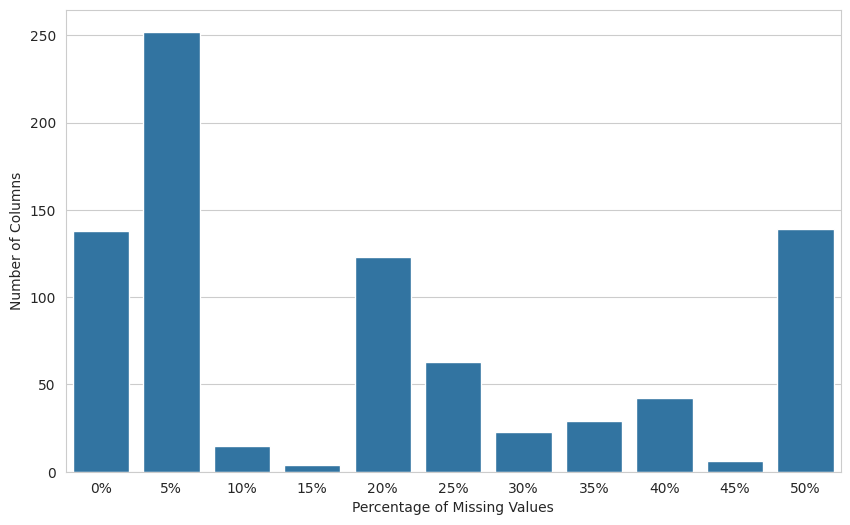

In [11]:
# Show in groups how much data is missing from the columns, in percentage of the total values of each column
missing_data_percentage = GDP_Total_clean.isnull().sum() / len(GDP_Total_clean) * 100
# print(missing_data_percentage)

# Separate the missing data for how many columns have only 5% of NaN, after ith 10% of Nan, continues this way until 50% of NaN
missing_data_none = missing_data_percentage[missing_data_percentage == 0]
missing_data_5 = missing_data_percentage[missing_data_percentage <= 5]
missing_data_10 = missing_data_percentage[(missing_data_percentage > 5) & (missing_data_percentage <= 10)]
missing_data_15 = missing_data_percentage[(missing_data_percentage > 10) & (missing_data_percentage <= 15)]
missing_data_20 = missing_data_percentage[(missing_data_percentage > 15) & (missing_data_percentage <= 20)]
missing_data_25 = missing_data_percentage[(missing_data_percentage > 20) & (missing_data_percentage <= 25)]
missing_data_30 = missing_data_percentage[(missing_data_percentage > 25) & (missing_data_percentage <= 30)]
missing_data_35 = missing_data_percentage[(missing_data_percentage > 30) & (missing_data_percentage <= 35)]
missing_data_40 = missing_data_percentage[(missing_data_percentage > 35) & (missing_data_percentage <= 40)]
missing_data_45 = missing_data_percentage[(missing_data_percentage > 40) & (missing_data_percentage <= 45)]
missing_data_50 = missing_data_percentage[missing_data_percentage > 45]

# Make a plot that show every missing data above in bars, and the number of missing values
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))
X = ['0%', '5%', '10%', '15%', '20%', '25%', '30%', '35%', '40%', '45%', '50%']
Y = [len(missing_data_none), len(missing_data_5), len(missing_data_10), len(missing_data_15), len(missing_data_20), len(missing_data_25), len(missing_data_30), len(missing_data_35), len(missing_data_40), len(missing_data_45), len(missing_data_50)]
sns.barplot(x=X, y=Y, ax=ax)
ax.set_xlabel('Percentage of Missing Values')
ax.set_ylabel('Number of Columns')


I will use 4 different methods: mean, median, K-NN with 5 neighboors and 30 neighboors too, Linear Regression, after evaluation will be see if is necessary the use of another method
Put print missing values for each step to visualize if runs correctly

I generate a copy of the GDP_Total_clean, where I delete some coluns in previous steps.

First I will replace 100 real values with predicted values to evaluate the methods


 Different methods of imputation:

       Method           MSE           MAE
2   KNN (k=5)  1.006154e+10  3.105124e+09
4  Regression  1.104714e+10  2.723238e+09
3  KNN (k=30)  8.660419e+10  2.203040e+10
1      Median  1.674737e+11  3.487590e+10
0        Mean  2.569894e+11  5.494978e+10


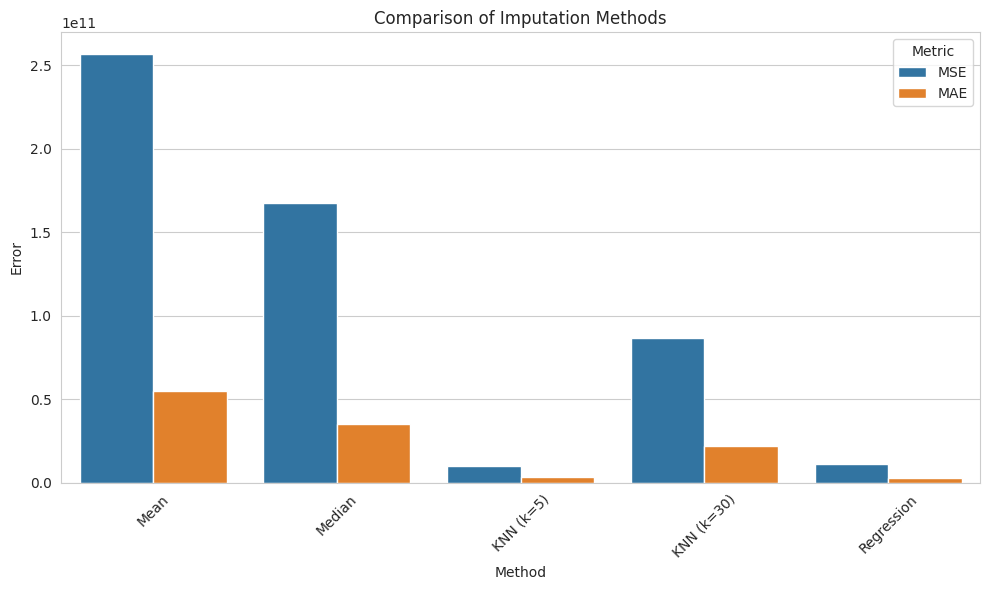

In [12]:
# Generates a copy of the table and replace 100 values with predicted one to see which method suits better

from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# n = 100
def mask_random_values(df, n=100, seed=42):
    np.random.seed(seed)
    df = df.copy()
    known_positions = [(i, j) for i in range(df.shape[0]) for j in range(df.shape[1]) if not pd.isnull(df.iat[i, j])]
    masked_positions = np.random.choice(len(known_positions), size=n, replace=False)
    masked_values = []

    for idx in masked_positions:
        i, j = known_positions[idx]
        masked_values.append((i, j, df.iat[i, j]))
        df.iat[i, j] = np.nan

    return df, masked_values

def compute_error(original_values, predicted_values):
    y_true = [val[2] for val in original_values]
    y_pred = [predicted_values.iloc[i, j] for i, j, _ in original_values]
    return {
        "MSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

# Prepare data, doing a copy
df_original = GDP_Total_clean.copy()
df_masked, masked_info = mask_random_values(df_original, n=100)

# Imputation byy mean
df_mean = df_masked.fillna(df_masked.mean())
error_mean = compute_error(masked_info, df_mean)

# Imputation by median
df_median = df_masked.fillna(df_masked.median())
error_median = compute_error(masked_info, df_median)

# Imputation by K-NN, with 5 neighboors
knn_imputer = KNNImputer(n_neighbors=5)
df_knn5 = pd.DataFrame(knn_imputer.fit_transform(df_masked), columns=df_masked.columns)
error_knn5 = compute_error(masked_info, df_knn5)

# Imputation by K-NN, with 30 neighboors
knn_imputer_30 = KNNImputer(n_neighbors=30)
df_knn30 = pd.DataFrame(knn_imputer_30.fit_transform(df_masked), columns=df_masked.columns)
error_knn30 = compute_error(masked_info, df_knn30)

# Imputation by regression
def regression_imputation(df):
    df_copy = df.copy()
    for col in df.columns[df.isnull().any()]:
        not_null = df_copy[col].notnull()
        null = df_copy[col].isnull()
        complete_cols = df_copy.columns[df_copy.notnull().all()]
        if len(complete_cols) == 0 or not_null.sum() < 10 or null.sum() == 0:
            continue
        X_train = df_copy.loc[not_null, complete_cols]
        y_train = df_copy.loc[not_null, col]
        X_pred = df_copy.loc[null, complete_cols]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_pred_scaled = scaler.transform(X_pred)

        model = LinearRegression()
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_pred_scaled)
        df_copy.loc[null, col] = y_pred
    return df_copy

df_regression = regression_imputation(df_masked)
error_regression = compute_error(masked_info, df_regression)

# Show the results
results = pd.DataFrame({
    'Method': ['Mean', 'Median', 'KNN (k=5)', 'KNN (k=30)', 'Regression'],
    'MSE': [error_mean['MSE'], error_median['MSE'], error_knn5['MSE'], error_knn30['MSE'], error_regression['MSE']],
    'MAE': [error_mean['MAE'], error_median['MAE'], error_knn5['MAE'], error_knn30['MAE'], error_regression['MAE']],
})

print("\n Different methods of imputation:\n")
print(results.sort_values('MSE'))

import seaborn as sns
import matplotlib.pyplot as plt

results_plot = results.melt(id_vars='Method', var_name='Metric', value_name='Value')

plt.figure(figsize=(10,6))
sns.barplot(data=results_plot, x='Method', y='Value', hue='Metric')
plt.title("Comparison of Imputation Methods")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The same process from above but using 200 values to replacement


 Different methods of imputation:

       Method           MSE           MAE
2   KNN (k=5)  2.406002e+10  6.505531e+09
4  Regression  2.535361e+10  6.105600e+09
3  KNN (k=30)  9.658877e+10  2.764444e+10
1      Median  2.119203e+11  5.852272e+10
0        Mean  2.763951e+11  7.392035e+10


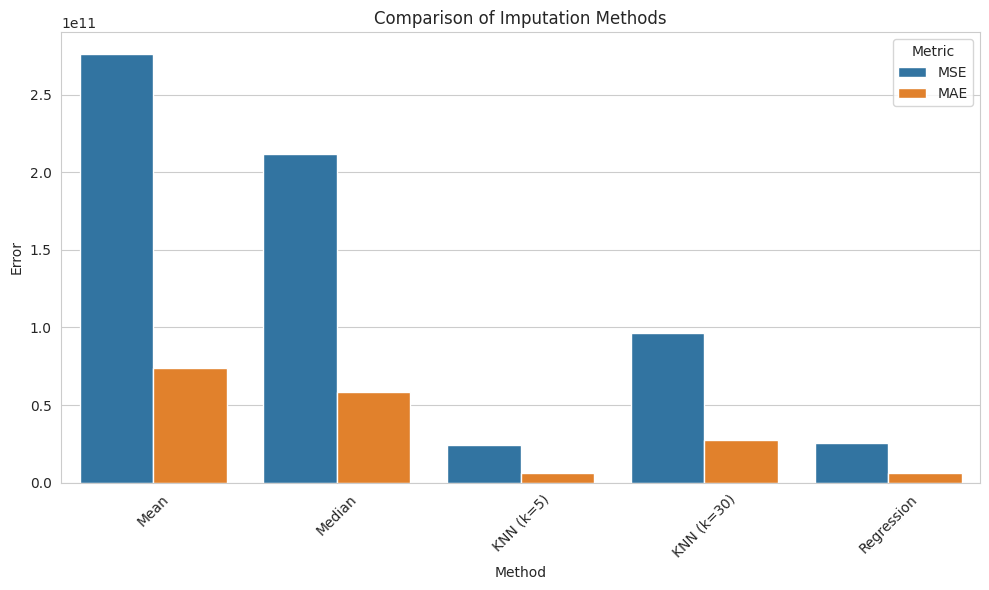

In [13]:
# Generates a copy of the table and replace 200 values with predicted one to see which method suits better

from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# n = 200
def mask_random_values(df, n=200, seed=42):
    np.random.seed(seed)
    df = df.copy()
    known_positions = [(i, j) for i in range(df.shape[0]) for j in range(df.shape[1]) if not pd.isnull(df.iat[i, j])]
    masked_positions = np.random.choice(len(known_positions), size=n, replace=False)
    masked_values = []

    for idx in masked_positions:
        i, j = known_positions[idx]
        masked_values.append((i, j, df.iat[i, j]))
        df.iat[i, j] = np.nan

    return df, masked_values

def compute_error(original_values, predicted_values):
    y_true = [val[2] for val in original_values]
    y_pred = [predicted_values.iloc[i, j] for i, j, _ in original_values]
    return {
        "MSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

# MSE calculates the average of the squared differences between predicted and actual values.
  # MSE penalizes larger errors more heavily due to the squaring, making it more sensitive to outliers
# MAE calculates the average of the absolute differences
  # MAE treats all errors equally

# Prepare data, doing a copy
df_original = GDP_Total_clean.copy()
df_masked, masked_info = mask_random_values(df_original, n=200)

# Imputation byy mean
df_mean = df_masked.fillna(df_masked.mean())
error_mean = compute_error(masked_info, df_mean)

# Imputation by median
df_median = df_masked.fillna(df_masked.median())
error_median = compute_error(masked_info, df_median)

# Imputation by K-NN, with 5 neighboors
knn_imputer = KNNImputer(n_neighbors=5)
df_knn5 = pd.DataFrame(knn_imputer.fit_transform(df_masked), columns=df_masked.columns)
error_knn5 = compute_error(masked_info, df_knn5)

# Imputation by K-NN, with 30 neighboors
knn_imputer_30 = KNNImputer(n_neighbors=30)
df_knn30 = pd.DataFrame(knn_imputer_30.fit_transform(df_masked), columns=df_masked.columns)
error_knn30 = compute_error(masked_info, df_knn30)

# Imputation by linear regression
def regression_imputation(df):
    df_copy = df.copy()
    for col in df.columns[df.isnull().any()]:
        not_null = df_copy[col].notnull()
        null = df_copy[col].isnull()
        complete_cols = df_copy.columns[df_copy.notnull().all()]
        if len(complete_cols) == 0 or not_null.sum() < 10 or null.sum() == 0:
            continue
        X_train = df_copy.loc[not_null, complete_cols]
        y_train = df_copy.loc[not_null, col]
        X_pred = df_copy.loc[null, complete_cols]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_pred_scaled = scaler.transform(X_pred)

        model = LinearRegression()
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_pred_scaled)
        df_copy.loc[null, col] = y_pred
    return df_copy

df_regression = regression_imputation(df_masked)
error_regression = compute_error(masked_info, df_regression)

# Show the results
results = pd.DataFrame({
    'Method': ['Mean', 'Median', 'KNN (k=5)', 'KNN (k=30)', 'Regression'],
    'MSE': [error_mean['MSE'], error_median['MSE'], error_knn5['MSE'], error_knn30['MSE'], error_regression['MSE']],
    'MAE': [error_mean['MAE'], error_median['MAE'], error_knn5['MAE'], error_knn30['MAE'], error_regression['MAE']],
})

print("\n Different methods of imputation:\n")
print(results.sort_values('MSE'))

import seaborn as sns
import matplotlib.pyplot as plt

results_plot = results.melt(id_vars='Method', var_name='Metric', value_name='Value')

plt.figure(figsize=(10,6))
sns.barplot(data=results_plot, x='Method', y='Value', hue='Metric')
plt.title("Comparison of Imputation Methods")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

I make a list to remember how to evaluate the errors

*   MSE calculates the average of the squared differences between predicted and actual values;
*   MSE penalizes larger errors more heavily due to the squaring, making it more sensitive to outliers;
*   MAE calculates the average of the absolute differences;
*   MAE treats all errors equally.

Analyzing the output from above I was surprised to see the Linear Regression could be one of to have least errors and surprise too when I adjusted the number of replacing values to 200 the replacement values have a worts behavior. But I decided to use K-NN with 5 neighboors. One of the reasons for these problems happens I believe is because of the short time series that I using, only 65 years, perhaps if it was possible to find this data in monthly basis it will suit better






In [14]:
# Impute missing values using KNN with 5 neighboors

knn_imputer = KNNImputer(n_neighbors=5)
GDP_imputed = pd.DataFrame(
    knn_imputer.fit_transform(GDP_Total_clean),
    columns=GDP_Total_clean.columns,
    index=GDP_Total_clean.index
)

# Check if after the imputation still have some missing value
print(f"Missing values after imputation: {GDP_imputed.isnull().sum().sum()}")
GDP_imputed.head()

Missing values after imputation: 0


,0,1,2,6,7,8,9,10,11,12,...,1494,1495,1496,1497,1498,1499,1501,1502,1503,1514
1960 [YR1960],91.302,10.03173,0.720167,552.179409,787.275368,6.281814,1.262101e+10,6.051,7.378400e+08,5813361.2,...,35.008597,33.317078,33.899729,63.173271,61.326072,62.001213,22.933431,1.768224e-13,30.625,31.544978
1961 [YR1961],90.889,10.03173,0.720167,552.179409,787.275368,6.420217,1.262101e+10,6.022,7.378400e+08,5813361.2,...,35.008597,33.317078,33.899729,63.173271,61.326072,62.001213,22.933431,2.446007e-13,30.625,31.544978
1962 [YR1962],90.139,10.03173,0.720167,552.179409,787.275368,4.008479,1.262101e+10,5.984,7.378400e+08,5813361.2,...,35.008597,33.317078,33.899729,63.173271,61.326072,62.001213,22.933431,3.748121e-13,30.625,31.544978
1963 [YR1963],89.118,10.03173,0.720167,552.179409,787.275368,8.933145,1.262101e+10,5.930,7.378400e+08,5813361.2,...,35.008597,33.317078,33.899729,63.173271,61.326072,62.001213,22.933431,6.508432e-13,30.625,31.544978
1964 [YR1964],87.591,10.03173,0.720167,552.179409,787.275368,6.460997,1.262101e+10,5.818,7.378400e+08,5813361.2,...,35.008597,33.317078,33.899729,63.173271,61.326072,62.001213,22.933431,1.247164e-12,30.625,31.544978


I came back here to adjust the data, that I will use on futures graphs

In [15]:
## Extract the data here, so can be used in future occasion
# Extract just the first column (index 0)
years_clean = [str(year).split(' ')[0] for year in GDP_imputed.index]
# Sho if it was extracted correctly
print(years_clean)

['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


That was the final of Data Preparation. Next I will train the model to predict the values. Always using the data from GDP_imputed after this step. **Now with the data complete and without errors I can go to the next step and work in the Predction model**

**It is necessary to use only one information, that will be GDP Absolute values and GDP growth too**

In [16]:
# Here I import all the libraries that will be necessary to elaborate the models
# If necesary, I come back here and add more
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

I come back here to comment that im my case I cannot use much sequential lenght, because my time series only have 65 periods of time. I tried more and happens erros because don't left much samples to test

# In the step I select only the values from GDP Absolute values
I checked the data that is showed here with the original data to confirm it is correct


# Models for Absolute GDP

In [17]:
# want to see the values inside specific column
GDP_imputed.iloc[10]
# want to see the values inside specific row
GDP_imputed.iloc[:,10]
# That is the information I looking for: Brazil,BRA,GDP (current US$),NY.GDP.MKTP.CD

,13
1960 [YR1960],1.703047e+10
1961 [YR1961],1.727594e+10
1962 [YR1962],1.923175e+10
1963 [YR1963],2.328771e+10
1964 [YR1964],2.096373e+10
...,...
2020 [YR2020],1.476107e+12
2021 [YR2021],1.670647e+12
2022 [YR2022],1.951924e+12
2023 [YR2023],2.191132e+12


In [18]:
# Show the Brazil GDP data from row 10 of the imputed dataset
Brazil_GDP_values = GDP_imputed.iloc[:,10].values # ------->>> This will be the database that will be use in next models
print(f"Total data points: {len(Brazil_GDP_values)}")
print(f"First 10 values: {Brazil_GDP_values[:10]}")
print(f"Last 10 values: {Brazil_GDP_values[-10:]}")
print(f"Data range: ${Brazil_GDP_values.min():,.2f} to ${Brazil_GDP_values.max():,.2f}")

# Check for any remaining NaN values, needs to be 0
nan_count = np.isnan(Brazil_GDP_values).sum()
print(f"NaN values in the data: {nan_count}")

Total data points: 65
First 10 values: [1.70304655e+10 1.72759404e+10 1.92317479e+10 2.32877129e+10
 2.09637337e+10 2.24655229e+10 2.82833237e+10 3.10863892e+10
 3.39304574e+10 3.71716408e+10]
Last 10 values: [1.80221221e+12 1.79569348e+12 2.06351498e+12 1.91693390e+12
 1.87328821e+12 1.47610723e+12 1.67064740e+12 1.95192394e+12
 2.19113177e+12 2.17941208e+12]
Data range: $17,030,465,539.39 to $2,616,156,223,917.69
NaN values in the data: 0


Doing others models I realize that some steps are similar for all of them, so I ust put these steps above all of them.

Other issue that happens are the number of the data series (only 65 years), so I need to adjust to discover what will be the best number os sequence lenght

In [19]:
# Load
data_2 = GDP_imputed.values

print(f"Dataset shape: {data_2.shape}")
print(f"Number of observations: {data_2.shape[0]}")
print(f"Number of variables: {data_2.shape[1]}")

# Normalize all variables
scaler = MinMaxScaler()
data_2_scaled = scaler.fit_transform(data_2)

# Adjust sequence length based on data size
seq_length = min(10, data_2.shape[0] // 3)
target_col = 10  # Absolute GDP column

print(f"Adjusted sequence length: {seq_length}")
print(f"Target column (Absolute GDP): {target_col}")

Dataset shape: (65, 696)
Number of observations: 65
Number of variables: 696
Adjusted sequence length: 10
Target column (Absolute GDP): 10


**First model - uses SimpleRNN, with seq_lenght=20 (Absolute GDP US$)**

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.6414 - val_loss: 1.1065
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - loss: 1.0445 - val_loss: 0.0178
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0459 - val_loss: 0.2783
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 0.3127 - val_loss: 0.2892
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.3235 - val_loss: 0.1210
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.1481 - val_loss: 0.0194
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0369 - val_loss: 0.0429
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


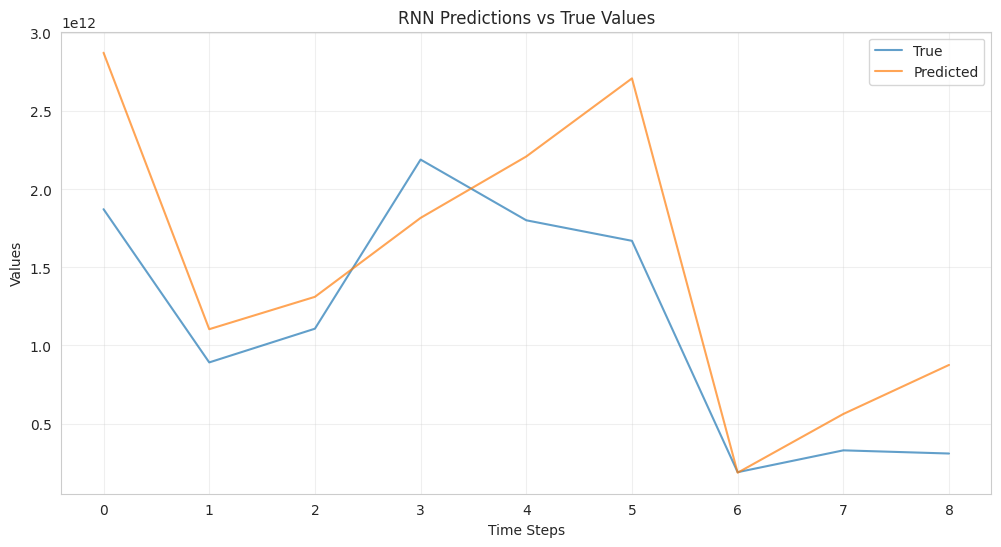

Simple RNN Absolute GDP - RMSE: 563553613433.34, MAE: 449631097204.06, R²: 0.3894


In [20]:
# First I will use the same steps as showed in RNN_Practical_Class.ipynb

# Standardize all variables and create sequences. Using range between 0 and 1 because there is only absolute values in this data
scaler = MinMaxScaler()
data_2_scaled = scaler.fit_transform(data_2)

# Scale only the target column
target_col = 10
target_scaler = MinMaxScaler()
target_data = data_2[:, target_col].reshape(-1, 1)
target_data_scaled = target_scaler.fit_transform(target_data)

# Create multivariables sequences
def create_sequences_multivariate(data, seq_length, target_col=10):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_col])
    return np.array(x), np.array(y)

seq_length = 20

x, y = create_sequences_multivariate(data_2_scaled, seq_length, target_col=10)

# I just comment the two lines below to not take much space
# print("A first value of a variable x:",x[0])
# print("\n A first value of a variable y:",y[0])

##Reshape the input data X to a 3D format required use in LSTM models:
##X.shape[0]: number of samples (training examples),
##X.shape[1]: sequence length (how many time steps per sample),
##X.shape[2]: number of features per time step (multivariate features).
# FIXED: Uncommented and corrected - for multivariate data, use x.shape[2] not 1
x = x.reshape((x.shape[0], x.shape[1], x.shape[2]))

# Split into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Will create an early stop to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

#Builds a simple RNN model to predict time series values
model_simple_rnn_1 = Sequential()
model_simple_rnn_1.add(SimpleRNN(50, activation='tanh', input_shape=(seq_length, x.shape[2])))
model_simple_rnn_1.add(Dense(1))
model_simple_rnn_1.compile(optimizer=Adam(), loss='mse')

# Train the model
history = model_simple_rnn_1.fit(x_train, y_train, epochs=20, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=True)

# Predict and plot results
y_pred = model_simple_rnn_1.predict(x_test)

# Inverse transform predictions using the correct scaler and reshaping
y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_inv = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

# Show the difference between the true values and the predicted values in a plot
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='True', alpha=0.7)
plt.plot(y_pred_inv, label='Predicted', alpha=0.7)
plt.title("RNN Predictions vs True Values")
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate metrics for errors
rmse_rnn_absolute_values_example_class = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae_rnn_absolute_values_example_class = mean_absolute_error(y_test_inv, y_pred_inv)
r2_rnn_absolute_values_example_class = r2_score(y_test_inv, y_pred_inv)

print(f"Simple RNN Absolute GDP - RMSE: {rmse_rnn_absolute_values_example_class:.2f}, MAE: {mae_rnn_absolute_values_example_class:.2f}, R²: {r2_rnn_absolute_values_example_class:.4f}")


**Second model - LTSM, with seq_lenght = 20 (Absolute GDP US$)**

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - loss: 0.8239 - val_loss: 0.2116
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.2899 - val_loss: 0.9381
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.5082 - val_loss: 0.4925
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.1521 - val_loss: 0.0829
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0479 - val_loss: 0.0141
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.1154 - val_loss: 0.0140
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0907 - val_loss: 0.0248
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0367 - val_loss: 0.0611
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0143 - val_loss: 0.1053
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0200 - val_loss: 0.1240
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0374 - val_loss: 0.0971
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 6.
1/1 ━━━━

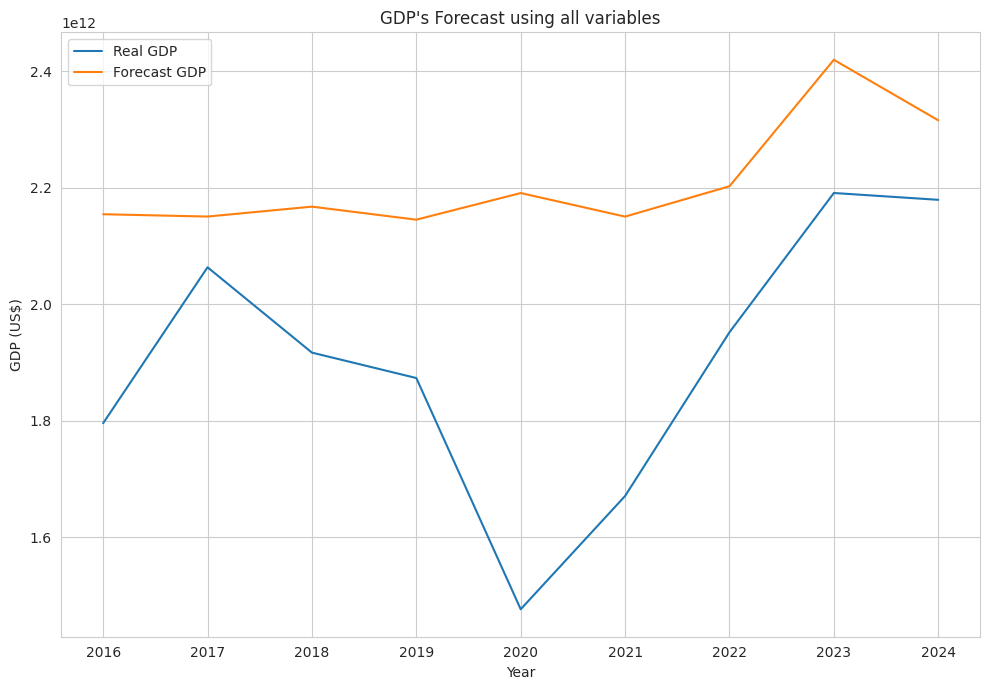

In [21]:
data_2 = GDP_imputed.values

# Standardize all variables
scaler = MinMaxScaler()
data_2_scaled = scaler.fit_transform(data_2)

# Create multivariables sequences
def create_sequences_multivariate(data, seq_length, target_col=10):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_col])
    return np.array(x), np.array(y)

seq_length = 20
x, y = create_sequences_multivariate(data_2_scaled, seq_length, target_col=10)

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

# Train the model
ltsm_model_1 = Sequential()
ltsm_model_1.add(LSTM(64, activation='tanh', input_shape=(seq_length, x.shape[2])))
ltsm_model_1.add(Dense(1))
ltsm_model_1.compile(optimizer='adam', loss='mse')

# Early stop
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Train
history = ltsm_model_1.fit(x_train, y_train, epochs=50, batch_size=16, validation_split=0.1, callbacks=[early_stop])

#Predict
y_pred = ltsm_model_1.predict(x_test)

# Reverts column of GDP:
pib_scaler = MinMaxScaler()
pib_scaler.fit(data_2[:, 10].reshape(-1, 1))

y_test_inv = pib_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = pib_scaler.inverse_transform(y_pred.reshape(-1, 1))

# Metrics
rmse_ltsm_1 = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae_ltsm_1 = mean_absolute_error(y_test_inv, y_pred_inv)
r2_ltsm_1 = r2_score(y_test_inv, y_pred_inv)

print(f"LTSM 1 - Absolute GDP RMSE: {rmse_ltsm_1:.2f}, MAE: {mae_ltsm_1:.2f}, R²: {r2_ltsm_1:.4f}")

n_samples = len(data_2) - seq_length  # Total of numbers that was created
train_size = int(n_samples * 0.8)     # How many sequences on train

# Show the years used in the train
years_test = years_clean[train_size + seq_length : train_size + seq_length + len(y_test)]

# Plot
plt.figure(figsize=(10,7))
plt.plot(years_test, y_test_inv, label='Real GDP')
plt.plot(years_test, y_pred_inv, label='Forecast GDP')
plt.title("GDP's Forecast using all variables")
plt.xlabel("Year")
plt.ylabel("GDP (US$)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Third model - uses Ridge Regression (Non sequential model), Alpha=10 (Absolute GDP US$)**

In [22]:
# Create features for non-sequential models
def create_features_non_sequential(data, seq_length, target_col=10):
    x, y = [], []
    for i in range(len(data) - seq_length):
        # Flatten last seq_length observations of all variables
        features = data[i:i+seq_length].flatten()
        x.append(features)
        y.append(data[i+seq_length, target_col])
    return np.array(x), np.array(y)

# For Ridge Regression (non-sequential)
x_flat, y_flat = create_features_non_sequential(data_2_scaled, seq_length, target_col)

# Split train/test - using temporal split (no shuffle for time series)
split_idx = int(len(x_flat) * 0.8)

x_flat_train, x_flat_test = x_flat[:split_idx], x_flat[split_idx:]
y_flat_train, y_flat_test = y_flat[:split_idx], y_flat[split_idx:]

# Scaler to reverse only GDP column
pib_scaler = MinMaxScaler()
pib_scaler.fit(data_2[:, target_col].reshape(-1, 1))

print("Flattened data shape:", x_flat.shape)
print("x_flat_train shape:", x_flat_train.shape)
print("y_flat_train shape:", y_flat_train.shape)

# Use Ridge instead of simple LinearRegression for better regularization
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(x_flat_train, y_flat_train)

# Predictions
y_pred_ridge = ridge_model.predict(x_flat_test)

# Reverse scaling
y_test_ridge_inv = pib_scaler.inverse_transform(y_flat_test.reshape(-1, 1))
y_pred_ridge_inv = pib_scaler.inverse_transform(y_pred_ridge.reshape(-1, 1))

# Metrics
rmse_ridge = np.sqrt(mean_squared_error(y_test_ridge_inv, y_pred_ridge_inv))
mae_ridge = mean_absolute_error(y_test_ridge_inv, y_pred_ridge_inv)
r2_ridge = r2_score(y_test_ridge_inv, y_pred_ridge_inv)

print(f"Ridge Regression Absolute GDP - RMSE: {rmse_ridge:.2f}, MAE: {mae_ridge:.2f}, R²: {r2_ridge:.4f}")

Flattened data shape: (45, 13920)
x_flat_train shape: (36, 13920)
y_flat_train shape: (36,)
Ridge Regression Absolute GDP - RMSE: 207512918037.43, MAE: 170473676409.91, R²: 0.1119


**Fourth model - uses Simple RNN with adjustments for previous one (Absolute GDP US$)**

In [23]:
# Create multivariate sequences for GDP prediction
def create_sequences_multivariate(data, seq_length, target_col=10):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_col])
    return np.array(x), np.array(y)

# For LSTM and RNN (sequential)
x_seq, y_seq = create_sequences_multivariate(data_2_scaled, seq_length, target_col)

# Split train/test - using temporal split (no shuffle for time series)
split_idx = int(len(x_seq) * 0.8)

x_seq_train, x_seq_test = x_seq[:split_idx], x_seq[split_idx:]
y_seq_train, y_seq_test = y_seq[:split_idx], y_seq[split_idx:]

# Scaler to reverse only GDP column
pib_scaler = MinMaxScaler()
pib_scaler.fit(data_2[:, target_col].reshape(-1, 1))

print("Sequential data shape:", x_seq.shape)
print("Training samples:", len(x_seq_train))
print("Test samples:", len(x_seq_test))

# More conservative architecture for small datasets
rnn_model_2 = Sequential([
    SimpleRNN(32, return_sequences=True, input_shape=(seq_length, x_seq.shape[2])),
    Dropout(0.2),
    SimpleRNN(16),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1)
])

rnn_model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Early stopping with more patience
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=0
)

# Training with smaller batch size for small datasets
history_rnn = rnn_model_2.fit(
    x_seq_train, y_seq_train,
    epochs=100,
    batch_size=4,  # Smaller batch size
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Predictions
y_pred_rnn = rnn_model_2.predict(x_seq_test, verbose=0)

# Reverse scaling
y_test_rnn_inv = pib_scaler.inverse_transform(y_seq_test.reshape(-1, 1))
y_pred_rnn_inv = pib_scaler.inverse_transform(y_pred_rnn.reshape(-1, 1))

# Metrics
rmse_rnn_2 = np.sqrt(mean_squared_error(y_test_rnn_inv, y_pred_rnn_inv))
mae_rnn_2 = mean_absolute_error(y_test_rnn_inv, y_pred_rnn_inv)
r2_rnn_2 = r2_score(y_test_rnn_inv, y_pred_rnn_inv)

print(f"Simple RNN_2 Absolute GDP - RMSE: {rmse_rnn_2:.2f}, MAE: {mae_rnn_2:.2f}, R²: {r2_rnn_2:.4f}")

Sequential data shape: (45, 20, 696)
Training samples: 36
Test samples: 9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Simple RNN_2 Absolute GDP - RMSE: 212403992792.27, MAE: 169475003227.61, R²: 0.0696


**Fifth model - using LTSM for second time, with different parameters (Absolute GDP US$)**

In [24]:
# LTSM 2 - second time using LTSM for Absolute GDP, adusting some parameters
ltsm_model_2 = Sequential([
    LSTM(32, return_sequences=True, input_shape=(seq_length, x_seq.shape[2])),
    Dropout(0.2),
    LSTM(16),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1)
])

ltsm_model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Training
history_lstm = ltsm_model_2.fit(
    x_seq_train, y_seq_train,
    epochs=100,
    batch_size=4,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Predictions
y_pred_ltsm = ltsm_model_2.predict(x_seq_test, verbose=0)

# Reverse scaling
y_pred_ltsm_inv = pib_scaler.inverse_transform(y_pred_ltsm.reshape(-1, 1))

# Metrics
rmse_ltsm_2 = np.sqrt(mean_squared_error(y_test_rnn_inv, y_pred_ltsm_inv))
mae_ltsm_2 = mean_absolute_error(y_test_rnn_inv, y_pred_ltsm_inv)
r2_ltsm_2 = r2_score(y_test_rnn_inv, y_pred_ltsm_inv)

print(f"LTSM_2 Absolute GDP - RMSE: {rmse_ltsm_2:.2f}, MAE: {mae_ltsm_2:.2f}, R²: {r2_ltsm_2:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LTSM_2 Absolute GDP - RMSE: 257361182374.13, MAE: 224829655687.83, R²: -0.3660


**Evaluation between the models of Absolute GDP US$ and comparing them**

In [25]:
print("Metrics for each model for Absolute GDP:")
print(f"Simple RNN 1 Absolute GDP     - RMSE: {rmse_rnn_absolute_values_example_class:.2f}, MAE: {mae_rnn_absolute_values_example_class:.2f}, R²: {r2_rnn_absolute_values_example_class:.4f}")
print(f"LTSM 1 Absolute GDP           - RMSE: {rmse_ltsm_1:.2f}, MAE: {mae_ltsm_1:.2f}, R²: {r2_ltsm_1:.4f}")
print(f"Ridge Regression Absolute GDP - RMSE: {rmse_ridge:.2f}, MAE: {mae_ridge:.2f}, R²: {r2_ridge:.4f}")
print(f"Simple RNN 2 Absolute GDP     - RMSE: {rmse_rnn_2:.2f}, MAE: {mae_rnn_2:.2f}, R²: {r2_rnn_2:.4f}")
print(f"LTSM_2 Absolute GDP           - RMSE: {rmse_ltsm_2:.2f}, MAE: {mae_ltsm_2:.2f}, R²: {r2_ltsm_2:.4f}")

# Determine best model based on R²
models_performance = {
    'Simple RNN 1 Absolute GDP': {'model': model_simple_rnn_1, 'r2': r2_rnn_absolute_values_example_class, 'type': 'sequential', 'predictions': y_pred_inv},
    'LTSM 1 Absolute GDP': {'model': ltsm_model_1, 'r2': r2_ltsm_1, 'type': 'sequential', 'predictions': y_pred_inv},
    'Ridge Regression Absolute GDP': {'model': ridge_model, 'r2': r2_ridge, 'type': 'flat', 'predictions': y_pred_ridge_inv},
    'Simple RNN 2 Absolute GDP': {'model': rnn_model_2, 'r2': r2_rnn_2, 'type': 'sequential', 'predictions': y_pred_rnn_inv},
    'LSTM 2 Absolute GDP': {'model': ltsm_model_2, 'r2': r2_ltsm_2, 'type': 'sequential', 'predictions': y_pred_ltsm_inv}
}

best_model_name = max(models_performance.keys(), key=lambda k: models_performance[k]['r2'])
best_model_info = models_performance[best_model_name]
print(f"\nBest model: {best_model_name} (R² = {best_model_info['r2']:.4f})")

Metrics for each model for Absolute GDP:
Simple RNN 1 Absolute GDP     - RMSE: 563553613433.34, MAE: 449631097204.06, R²: 0.3894
LTSM 1 Absolute GDP           - RMSE: 357241812087.67, MAE: 308864913768.30, R²: -1.6320
Ridge Regression Absolute GDP - RMSE: 207512918037.43, MAE: 170473676409.91, R²: 0.1119
Simple RNN 2 Absolute GDP     - RMSE: 212403992792.27, MAE: 169475003227.61, R²: 0.0696
LTSM_2 Absolute GDP           - RMSE: 257361182374.13, MAE: 224829655687.83, R²: -0.3660

Best model: Simple RNN 1 Absolute GDP (R² = 0.3894)


# In the next step I select only the values from GDP Growth
I checked the data that is showed here with the original data to confirm it is correct

Perhaps will better to work with numeric data with low values. Beacuse that I will do that approach too.

# Models for GDP growth (%)

In [26]:
# want to see the values inside specific column eleventh
GDP_imputed.iloc[11]
# want to see the values inside specific row eleventh
GDP_imputed.iloc[:,11]
# That is the information I looking for: Brazil,BRA,GDP growth (annual %),NY.GDP.MKTP.KD.ZG

,14
1960 [YR1960],4.320000
1961 [YR1961],8.600000
1962 [YR1962],6.600000
1963 [YR1963],0.600000
1964 [YR1964],3.400000
...,...
2020 [YR2020],-3.276759
2021 [YR2021],4.762604
2022 [YR2022],3.016694
2023 [YR2023],3.241655


In [27]:
# Show the Brazil GDP growth data from row 11 of the imputed dataset
print("Extracting Brazil GDP data from GDP growth...")
Brazil_GDP_Growth = GDP_imputed.iloc[:,11].values # ------->>> This will be the database that will be use in next models
print(f"Total data points: {len(Brazil_GDP_Growth)}")
print(f"First 10 values: {Brazil_GDP_Growth[:10]}")
print(f"Last 10 values: {Brazil_GDP_Growth[-10:]}")
print(f"Data range: ${Brazil_GDP_Growth.min():,.2f} to ${Brazil_GDP_Growth.max():,.2f}")

# Check for any remaining NaN values, needs to be 0
nan_count = np.isnan(Brazil_GDP_Growth).sum()
print(f"NaN values in the data: {nan_count}")

Extracting Brazil GDP data from GDP growth...
Total data points: 65
First 10 values: [4.32 8.6  6.6  0.6  3.4  2.4  6.7  4.2  9.8  9.5 ]
Last 10 values: [-3.54576339 -3.27591691  1.32286905  1.78366676  1.22077782 -3.2767588
  4.76260438  3.01669435  3.24165533  3.39586645]
Data range: $-4.35 to $13.97
NaN values in the data: 0


Just like above, the information that is common for all models I will put below in the code

In [28]:
# Load
data_3 = GDP_imputed.values

print(f"Dataset shape: {data_3.shape}")
print(f"Number of observations: {data_3.shape[0]}")
print(f"Number of variables: {data_3.shape[1]}")

# Standardize all variables
scaler = MinMaxScaler()
data_3_scaled = scaler.fit_transform(data_3)

# Adjust sequence length based on data size
seq_length_2 = min(10, data_3.shape[0] // 3)
target_col_2 = 11  # GDP growth column

print(f"Adjusted sequence length: {seq_length_2}")
print(f"Target column (Growth): {target_col_2}")

Dataset shape: (65, 696)
Number of observations: 65
Number of variables: 696
Adjusted sequence length: 10
Target column (Growth): 11


**First model - SimpleRNN, with seq_lenght = 20 (GDP's Growth - %)**

Adjusted sequence length: 10
Dataset shape: (65, 696)
Training set - X: (44, 10, 696), Y: (44,)
Test set - X: (11, 10, 696), Y: (11,)
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 385ms/step - loss: 0.5784 - val_loss: 0.2410
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.3354 - val_loss: 0.8570
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.6635 - val_loss: 0.0560
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0825 - val_loss: 0.1230
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.1600 - val_loss: 0.1872
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.1860 - val_loss: 0.0386
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0536 - val_loss: 0.0296
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0654 - val_loss: 0.0695
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0972 - val_loss: 0.0327
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0530 - val_loss: 0.0204
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0362 - val_loss: 0.0610
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0524 - val_loss: 0.0786
Epoch 13

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
Predictions shape: (11,)
Test values shape: (11,)


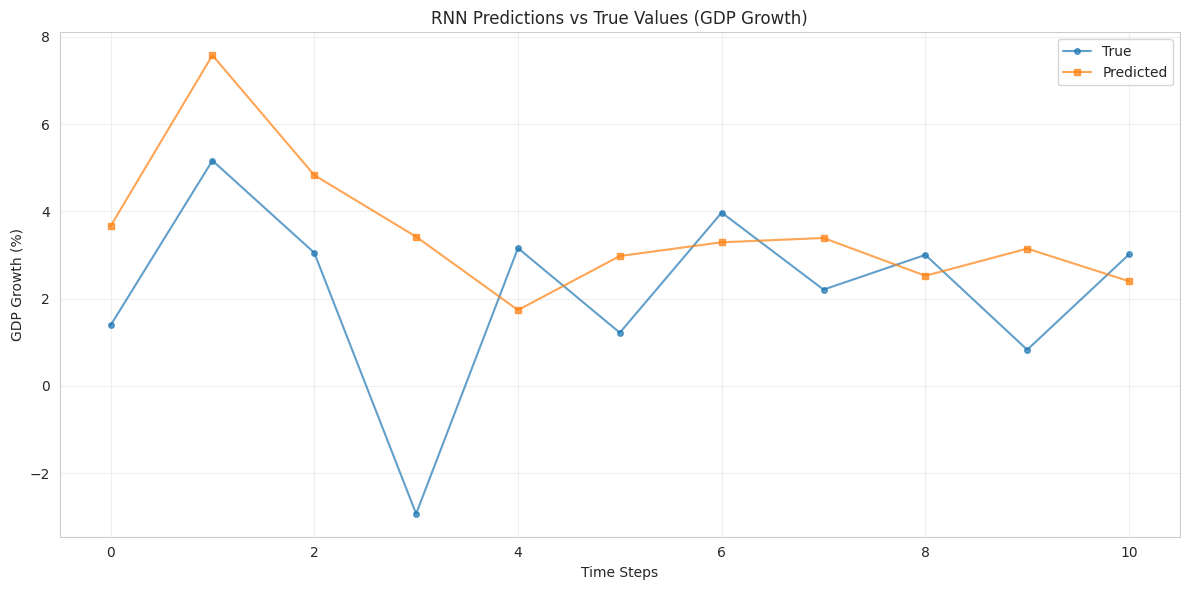


Model Performance:
SimpleRNN GDP Growth - RMSE: 2.4764, MAE: 1.9341, R²: -0.5084

Diagnostic Information:
Original data range: -4.35 to 13.97
Prediction range: 1.74 to 7.58
True test range: -2.93 to 5.17


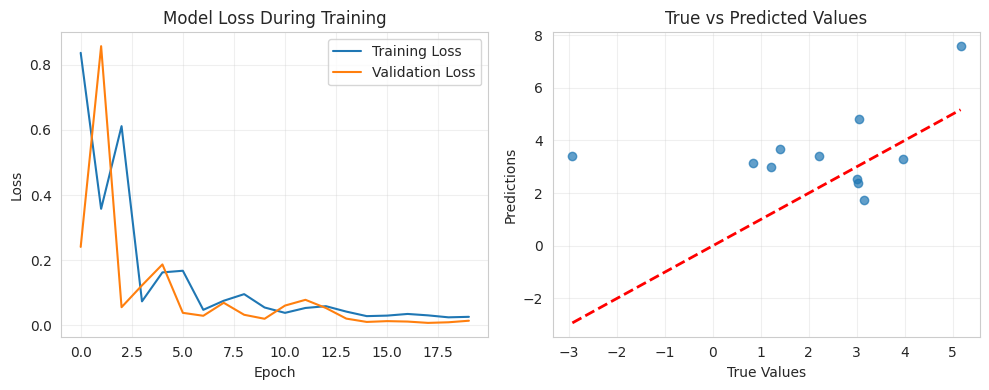

In [29]:
# First I will use the same steps as showed in RNN_Practical_Class.ipynb

# Standardize all variables
scaler = MinMaxScaler()
data_3_scaled = scaler.fit_transform(data_3)

# Adjust sequence length based on data size
seq_length_2 = min(10, data_3.shape[0] // 3)
target_col_2 = 11  # GDP growth

print(f"Adjusted sequence length: {seq_length_2}")
print(f"Dataset shape: {data_3.shape}")

# Scale only the target column
target_scaler = MinMaxScaler()
target_data = data_3[:, target_col_2].reshape(-1, 1)
target_data_scaled = target_scaler.fit_transform(target_data)

# Create multivariate sequences with consistent variable names
def create_sequences_multivariate(data, seq_length, target_col):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])          # FIXED: use seq_length parameter
        y.append(data[i+seq_length, target_col]) # FIXED: use seq_length parameter
    return np.array(x), np.array(y)

# Use seq_length_2 consistently
x, y = create_sequences_multivariate(data_3_scaled, seq_length_2, target_col_2)

# Reshape the input data X to a 3D format required for RNN models:
# X.shape[0]: number of samples (training examples),
# X.shape[1]: sequence length (how many time steps per sample),
# X.shape[2]: number of features per time step (multivariate features).
x = x.reshape((x.shape[0], x.shape[1], x.shape[2]))

# Split into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Training set - X: {x_train.shape}, Y: {y_train.shape}")
print(f"Test set - X: {x_test.shape}, Y: {y_test.shape}")

# Will create an early stop to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Builds a simple RNN model to predict time series values
# Use seq_length_2 for input_shape
model_simple_rnn_3 = Sequential()
model_simple_rnn_3.add(SimpleRNN(50, activation='tanh', input_shape=(seq_length_2, x.shape[2])))
model_simple_rnn_3.add(Dense(1))
model_simple_rnn_3.compile(optimizer=Adam(), loss='mse')

# Train the model
history = model_simple_rnn_3.fit(
    x_train, y_train,
    epochs=20,
    batch_size=min(32, len(x_train)//2),  # Adjust batch size for small datasets
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=True
)

# Predict and plot results
y_pred = model_simple_rnn_3.predict(x_test)

# Inverse transform predictions using the correct scaler and reshaping
y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_inv = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

print(f"Predictions shape: {y_pred_inv.shape}")
print(f"Test values shape: {y_test_inv.shape}")

# Show the difference between the true values and the predicted values in a plot
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='True', alpha=0.7, marker='o', markersize=4)
plt.plot(y_pred_inv, label='Predicted', alpha=0.7, marker='s', markersize=4)
plt.title("RNN Predictions vs True Values (GDP Growth)")
plt.xlabel("Time Steps")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate metrics for errors
rmse_rnn_3 = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae_rnn_3 = mean_absolute_error(y_test_inv, y_pred_inv)
r2_rnn_3 = r2_score(y_test_inv, y_pred_inv)

print(f"\nModel Performance:")
print(f"SimpleRNN GDP Growth - RMSE: {rmse_rnn_3:.4f}, MAE: {mae_rnn_3:.4f}, R²: {r2_rnn_3:.4f}")

# Additional diagnostic information
print(f"\nDiagnostic Information:")
print(f"Original data range: {data_3[:, target_col_2].min():.2f} to {data_3[:, target_col_2].max():.2f}")
print(f"Prediction range: {y_pred_inv.min():.2f} to {y_pred_inv.max():.2f}")
print(f"True test range: {y_test_inv.min():.2f} to {y_test_inv.max():.2f}")

# Show training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test_inv, y_pred_inv, alpha=0.7)
plt.plot([y_test_inv.min(), y_test_inv.max()], [y_test_inv.min(), y_test_inv.max()], 'r--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Second model - LTSM, with seq_lenght = 20 (GDP's Growth - %)**

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 461ms/step - loss: 0.8784 - val_loss: 1.8692
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.4488 - val_loss: 0.0302
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.1452 - val_loss: 0.3186
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.2709 - val_loss: 0.1380
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.1135 - val_loss: 0.0177
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0420 - val_loss: 0.0854
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0613 - val_loss: 0.1673
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.1022 - val_loss: 0.1623
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0827 - val_loss: 0.1134
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0542 - val_loss: 0.0576
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
LTSM Growth 1 - RMSE: 3.89, MAE: 3.42, R²: -1.0897


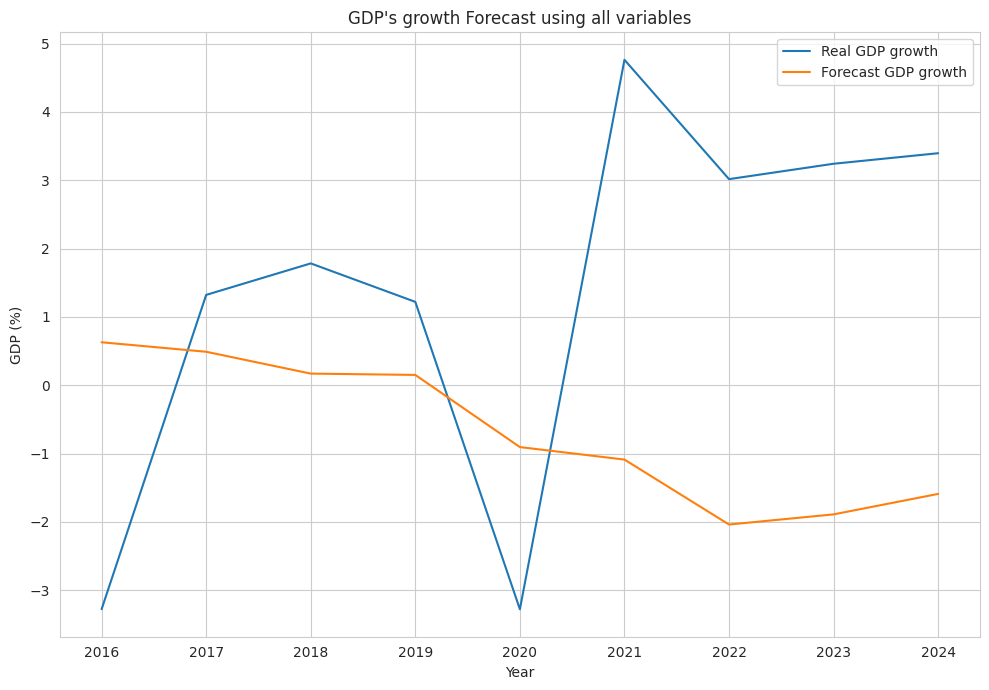

In [30]:
data_3 = GDP_imputed.values

# Standardize all variables
growth_scaler = MinMaxScaler()
growth_scaler.fit(data_3[:, 11].reshape(-1, 1)) # Column for GDP growth

# Create multivariables sequences
def create_sequences_multivariate(data, seq_length, target_col=11): # Here I select the GDP's growth column
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_col])
    return np.array(x), np.array(y)

seq_length = 20
x, y = create_sequences_multivariate(data_3_scaled, seq_length, target_col=11) # And here too the same column of growth

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

# Train the model
ltsm_model_3 = Sequential()
ltsm_model_3.add(LSTM(64, activation='tanh', input_shape=(seq_length, x.shape[2])))
ltsm_model_3.add(Dense(1))
ltsm_model_3.compile(optimizer='adam', loss='mse')

# Early stop
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Train
history = ltsm_model_3.fit(x_train, y_train, epochs=50, batch_size=16, validation_split=0.1, callbacks=[early_stop])

#Predict
y_pred = ltsm_model_3.predict(x_test)

# Reverts column of GDP:
pib_scaler = MinMaxScaler()
pib_scaler.fit(data_3[:, 10].reshape(-1, 1))

y_test_inv = growth_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = growth_scaler.inverse_transform(y_pred.reshape(-1, 1))

# Metrics
rmse_ltsm_3 = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae_ltsm_3 = mean_absolute_error(y_test_inv, y_pred_inv)
r2_ltsm_3 = r2_score(y_test_inv, y_pred_inv)

print(f"LTSM Growth 1 - RMSE: {rmse_ltsm_3:.2f}, MAE: {mae_ltsm_3:.2f}, R²: {r2_ltsm_3:.4f}")

n_samples = len(data_3) - seq_length  # Total of numbers that was created
train_size = int(n_samples * 0.8)     # How many sequences on train

# Show the years used in the train
years_test = years_clean[train_size + seq_length : train_size + seq_length + len(y_test)]

# Plot
plt.figure(figsize=(10,7))
plt.plot(years_test, y_test_inv, label='Real GDP growth')
plt.plot(years_test, y_pred_inv, label='Forecast GDP growth')
plt.title("GDP's growth Forecast using all variables")
plt.xlabel("Year")
plt.ylabel("GDP (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Third model - uses Ridge Regression (Non sequential model), Alpha=10 (GDP's Growth - %)**

In [31]:
# Create features for non-sequential models
def create_features_non_sequential(data, seq_length, target_col=11):
    x, y = [], []
    for i in range(len(data) - seq_length):
        # Flatten last seq_length observations of all variables
        features = data[i:i+seq_length].flatten()
        x.append(features)
        y.append(data[i+seq_length, target_col])
    return np.array(x), np.array(y)

# For Ridge Regression (non-sequential)
x_flat, y_flat = create_features_non_sequential(data_3_scaled, seq_length, target_col_2)

# Split train/test - using temporal split (no shuffle for time series)
split_idx = int(len(x_flat) * 0.8)

x_flat_train, x_flat_test = x_flat[:split_idx], x_flat[split_idx:]
y_flat_train, y_flat_test = y_flat[:split_idx], y_flat[split_idx:]

# Scaler to reverse only GDP column
growth_scaler = MinMaxScaler()
growth_scaler.fit(data_3[:, target_col].reshape(-1, 1))

print("Flattened data shape:", x_flat.shape)
print("x_flat_train shape:", x_flat_train.shape)
print("y_flat_train shape:", y_flat_train.shape)

# Use Ridge instead of simple LinearRegression for better regularization
ridge_model_2 = Ridge(alpha=10.0)
ridge_model_2.fit(x_flat_train, y_flat_train)

# Predictions
y_pred_ridge = ridge_model_2.predict(x_flat_test)

# Reverse scaling
y_test_ridge_inv = growth_scaler.inverse_transform(y_flat_test.reshape(-1, 1))
y_pred_ridge_inv = growth_scaler.inverse_transform(y_pred_ridge.reshape(-1, 1))

# Metrics
rmse_ridge_2 = np.sqrt(mean_squared_error(y_test_ridge_inv, y_pred_ridge_inv))
mae_ridge_2 = mean_absolute_error(y_test_ridge_inv, y_pred_ridge_inv)
r2_ridge_2 = r2_score(y_test_ridge_inv, y_pred_ridge_inv)

print(f"Ridge Regression Growth - RMSE: {rmse_ridge_2:.2f}, MAE: {mae_ridge_2:.2f}, R²: {r2_ridge_2:.4f}")

Flattened data shape: (45, 13920)
x_flat_train shape: (36, 13920)
y_flat_train shape: (36,)
Ridge Regression Growth - RMSE: 535333803298.28, MAE: 492667804275.60, R²: -0.9651


**Fourth model - uses Simple RNN with adjustments for previous one, Alpha=10 (GDP's Growth - %)**

In [32]:
data_3 = GDP_imputed.values
seq_length = 20
target_col_2 = 11

scaler = MinMaxScaler(feature_range=(-1, 1))  # Use -1 to 1 for growth rates
data_3_scaled = scaler.fit_transform(data_3)

seq_length = min(10, data_3.shape[0] // 4)

# Create multivariate sequences for GDP prediction
def create_sequences_multivariate(data_3, seq_length, target_col=11):
    x, y = [], []
    for i in range(len(data_3) - seq_length):
        # Input: sequence of all variables
        x.append(data_3[i:i+seq_length])
        # Target: next value of target column
        y.append(data_3[i+seq_length, target_col])
    return np.array(x), np.array(y)

# For creating sequences
x_seq, y_seq = create_sequences_multivariate(data_3_scaled, seq_length, target_col_2)

# Split train/test - using temporal split (no shuffle for time series)
split_idx = int(len(x_seq) * 0.8)

x_seq_train, x_seq_test = x_seq[:split_idx], x_seq[split_idx:]
y_seq_train, y_seq_test = y_seq[:split_idx], y_seq[split_idx:]

# Scaler to reverse only GDP column
growth_scaler = MinMaxScaler(feature_range=(-1, 1))
growth_scaler.fit(data_3[:, target_col_2].reshape(-1, 1))

# More conservative architecture for small datasets          --------------------------
rnn_model_4 = Sequential([
    SimpleRNN(16, return_sequences=True, input_shape=(seq_length, x_seq.shape[2])),  # ----
    Dropout(0.1),                 # ----
    SimpleRNN(8),                 # ----
    Dropout(0.1),                 # ----
    Dense(4, activation='relu'),  # ----
    Dense(1)
])

rnn_model_4.compile(
    optimizer=Adam(learning_rate=0.002),
    loss='mse',
    metrics=['mae']
)

# Early stopping with more patience
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,                           # -------------------
    restore_best_weights=True,
    verbose=1
)

batch_size = min(2, len(x_seq_train))      # ----
validation_split = 0.15 if len(x_seq_train) > 10 else 0.1

# Training with smaller batch size for small datasets
history_rnn = rnn_model_4.fit(
    x_seq_train, y_seq_train,
    epochs=100,
    batch_size=batch_size,
    validation_split=validation_split,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
y_pred_rnn = rnn_model_4.predict(x_seq_test, verbose=0)

# Reverse scaling
y_test_rnn_inv = growth_scaler.inverse_transform(y_seq_test.reshape(-1, 1))
y_pred_rnn_inv = growth_scaler.inverse_transform(y_pred_rnn.reshape(-1, 1))

# Flatten for metrics calculation
y_test_rnn_inv = y_test_rnn_inv.flatten()
y_pred_rnn_inv = y_pred_rnn_inv.flatten()

# Metrics
rmse_rnn_4 = np.sqrt(mean_squared_error(y_test_rnn_inv, y_pred_rnn_inv))
mae_rnn_4 = mean_absolute_error(y_test_rnn_inv, y_pred_rnn_inv)
r2_rnn_4 = r2_score(y_test_rnn_inv, y_pred_rnn_inv)

print(f"Simple RNN 2 GDP Growth - RMSE: {rmse_rnn_4:.2f}, MAE: {mae_rnn_4:.2f}, R²: {r2_rnn_4:.4f}")

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.2901 - mae: 0.4214 - val_loss: 0.7721 - val_mae: 0.7769
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2302 - mae: 0.3567 - val_loss: 0.4970 - val_mae: 0.6178
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1711 - mae: 0.2972 - val_loss: 0.4804 - val_mae: 0.5502
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2380 - mae: 0.3922 - val_loss: 0.4462 - val_mae: 0.5683
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2167 - mae: 0.3626 - val_loss: 0.5013 - val_mae: 0.5778
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2332 - mae: 0.3815 - val_loss: 0.6152 - val_mae: 0.6338
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1642 - mae: 0.3015 - val_loss: 0.6859 - val_mae: 0.6700
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1773 - mae: 0.3077 - val_loss: 0.7524 - val_mae: 0.7049
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2132 -

**Fifth model - using LTSM for second time, with different parameters (GDP's Growth - %)**

In [33]:
# LTSM 4 - second time using LTSM for GDP's Growth, adusting some parameters
ltsm_model_4 = Sequential([
    LSTM(32, return_sequences=True, input_shape=(seq_length_2, x_seq.shape[2])),
    Dropout(0.2),
    LSTM(16),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1)
])

ltsm_model_4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Training
history_lstm = ltsm_model_4.fit(
    x_seq_train, y_seq_train,
    epochs=100,
    batch_size=4,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Predictions
y_pred_ltsm = ltsm_model_4.predict(x_seq_test, verbose=0)

# Reverse scaling
y_pred_ltsm_inv = pib_scaler.inverse_transform(y_pred_ltsm.reshape(-1, 1))

# Metrics
rmse_ltsm_4 = np.sqrt(mean_squared_error(y_test_rnn_inv, y_pred_ltsm_inv))
mae_ltsm_4 = mean_absolute_error(y_test_rnn_inv, y_pred_ltsm_inv)
r2_ltsm_4 = r2_score(y_test_rnn_inv, y_pred_ltsm_inv)

print(f"LTSM_4 GDP Growwth - RMSE: {rmse_ltsm_4:.2f}, MAE: {mae_ltsm_4:.2f}, R²: {r2_ltsm_4:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 25.
LTSM_4 GDP Growwth - RMSE: 232238091463.59, MAE: 193334119946.25, R²: -6824841716218305970176.0000


**Evaluation between the models of GDP's growth % and comparing them**

In [34]:
print("Metrics for each model for GDP growth:")
print(f"Simple RNN 3 GDP Growth       - RMSE: {rmse_rnn_3:.2f}, MAE: {mae_rnn_3:.2f}, R²: {r2_rnn_3:.4f}")
print(f"LTSM 3 GDP Growth             - RMSE: {rmse_ltsm_3:.2f}, MAE: {mae_ltsm_3:.2f}, R²: {r2_ltsm_3:.4f}")
print(f"Ridge Regression 2 GDP Growth - RMSE: {rmse_ridge_2:.2f}, MAE: {mae_ridge_2:.2f}, R²: {r2_ridge_2:.4f}")
print(f"Simple RNN 4 GDP Growth       - RMSE: {rmse_rnn_4:.2f}, MAE: {mae_rnn_4:.2f}, R²: {r2_rnn_4:.4f}")
print(f"LTSM 4 GDP Growth             - RMSE: {rmse_ltsm_4:.2f}, MAE: {mae_ltsm_4:.2f}, R²: {r2_ltsm_4:.4f}")

# Determine best model based on R²
models_performance = {
    'Simple RNN 1 GDPs Growth': {'model': model_simple_rnn_1, 'r2': r2_rnn_absolute_values_example_class, 'type': 'sequential', 'predictions': y_pred_inv},
    'LTSM 1 GDPs Growth': {'model': ltsm_model_1, 'r2': r2_ltsm_1, 'type': 'sequential', 'predictions': y_pred_inv},
    'Ridge Regression GDPs Growth': {'model': ridge_model_2, 'r2': r2_ridge_2, 'type': 'flat', 'predictions': y_pred_ridge_inv},
    'Simple RNN 2 GDPs Growth': {'model': rnn_model_4, 'r2': r2_rnn_2, 'type': 'sequential', 'predictions': y_pred_rnn_inv},
    'LSTM 2 GDPs Growth': {'model': ltsm_model_4, 'r2': r2_ltsm_4, 'type': 'sequential', 'predictions': y_pred_ltsm_inv}
}

best_model_name = max(models_performance.keys(), key=lambda k: models_performance[k]['r2'])
best_model_info = models_performance[best_model_name]
print(f"\nBest model: {best_model_name} (R² = {best_model_info['r2']:.4f})")

Metrics for each model for GDP growth:
Simple RNN 3 GDP Growth       - RMSE: 2.48, MAE: 1.93, R²: -0.5084
LTSM 3 GDP Growth             - RMSE: 3.89, MAE: 3.42, R²: -1.0897
Ridge Regression 2 GDP Growth - RMSE: 535333803298.28, MAE: 492667804275.60, R²: -0.9651
Simple RNN 4 GDP Growth       - RMSE: 7.90, MAE: 7.37, R²: -6.8943
LTSM 4 GDP Growth             - RMSE: 232238091463.59, MAE: 193334119946.25, R²: -6824841716218305970176.0000

Best model: Simple RNN 1 GDPs Growth (R² = 0.3894)


#Comments

Comparision between all the models

In [39]:
print("Absolute GDP Models:")
print(f"  Simple RNN 1: R² = {r2_rnn_absolute_values_example_class:.4f}")
print(f"  LSTM 1:       R² = {r2_ltsm_1:.4f}")
print(f"  Ridge Reg:    R² = {r2_ridge:.4f}")
print(f"  Simple RNN 2: R² = {r2_rnn_2:.4f}")
print(f"  LSTM 2:       R² = {r2_ltsm_2:.4f}")

print("\nGrowth Models:")
print(f"  Simple RNN 3: R² = {r2_rnn_3:.4f}")
print(f"  LSTM 3:       R² = {r2_ltsm_3:.4f}")
print(f"  Ridge Reg 2:  R² = {r2_ridge_2:.4f}")
print(f"  Simple RNN 4: R² = {r2_rnn_4:.4f}")
print(f"  LSTM 4:       R² = {r2_ltsm_4:.4f}")

Absolute GDP Models:
  Simple RNN 1: R² = 0.3894
  LSTM 1:       R² = -1.6320
  Ridge Reg:    R² = 0.1119
  Simple RNN 2: R² = 0.0696
  LSTM 2:       R² = -0.3660

Growth Models:
  Simple RNN 3: R² = -0.5084
  LSTM 3:       R² = -1.0897
  Ridge Reg 2:  R² = -0.9651
  Simple RNN 4: R² = -6.8943
  LSTM 4:       R² = -6824841716218305970176.0000


All models from Absolute GDP were worsening in each attempts
The major problem probably is the Curse of Dimensionality

Outputs Numbers of 65 vs 696 variables = Ratio de 1:10.7
For my research the Neural Networks ork better with large amounts of data, at least 10x more series than variables, so in my case it will be necessary at least 7,000 outputs numbers.
It will be possible to estimate that if the period of the data was specified in months instead of years

Other point it's the difference between the numbers when working with Absolute GDP, numbers varies between billions and trillions

Maybe using PCA or feature selection to reduce the number of input features.

One of the approaches I tought is find which data is more related to the Absolute GDP and to GDP's growth, so I can give more focus on these variables, in response to gew that I have

In [57]:
# Calculate correlation with target variables
import pandas as pd

# Convert to DataFrame for easier correlation analysis
df_temp = pd.DataFrame(data_2, columns=[f'var_{i}' for i in range(data_2.shape[1])])
df_temp['gdp_absolute'] = data_2[:, 10]
df_temp['gdp_growth'] = data_3[:, 11]

# Correlation for Absolute GDP
corr_abs = df_temp.corr()['gdp_absolute'].abs().sort_values(ascending=False)
top_features_abs = corr_abs.head(13).index[1:]
least_features_abs = corr_abs.tail(10).index

print("\nMost variables correlated with Absolute GDP:")
for i, feature in enumerate(top_features_abs, 1):
    print(f"{i:2d}. {feature}: {corr_abs[feature]:.4f}")

print("\nVariables more poorly correlated with Absolute GDP:")
for i, feature in enumerate(least_features_abs, 1):
    print(f"{i:2d}. {feature}: {corr_abs[feature]:.4f}")

# Create datasets
selected_most = [int(f.split('_')[1]) for f in top_features_abs if f.startswith('var_')]
selected_least = [int(f.split('_')[1]) for f in least_features_abs if f.startswith('var_')]

data_most_abs = data_2[:, selected_most + [11]]
data_least_abs = data_2[:, selected_least + [11]]

# GDP growth correlation
corr_growth = df_temp.corr()['gdp_growth'].abs().sort_values(ascending=False)
top_features_growth = corr_growth.head(13).index[1:]
least_features_growth = corr_growth.tail(10).index

print("\nMost variables correlated with GDP Growth:")
for i, feature in enumerate(top_features_growth, 1):
    print(f"{i:2d}. {feature}: {corr_growth[feature]:.4f}")

print("\nVariables more poorly correlated with GDP Growth:")
for i, feature in enumerate(least_features_growth, 1):
    print(f"{i:2d}. {feature}: {corr_growth[feature]:.4f}")

# Create datasets
selected_most_growth = [int(f.split('_')[1]) for f in top_features_growth if f.startswith('var_')]
selected_least_growth = [int(f.split('_')[1]) for f in least_features_growth if f.startswith('var_')]

data_most_growth = data_3[:, selected_most_growth + [11]]
data_least_growth = data_3[:, selected_least_growth + [11]]

print(f"\nDataset shapes:")
print(f"Most correlated (Abs GDP): {data_most_abs.shape}")
print(f"Least correlated (Abs GDP): {data_least_abs.shape}")
print(f"Most correlated (Growth): {data_most_growth.shape}")
print(f"Least correlated (Growth): {data_least_growth.shape}")


Most variables correlated with Absolute GDP:
 1. var_10: 1.0000
 2. var_242: 0.9999
 3. var_273: 0.9998
 4. var_199: 0.9993
 5. var_288: 0.9992
 6. var_237: 0.9980
 7. var_222: 0.9969
 8. var_282: 0.9964
 9. var_45: 0.9946
10. var_623: 0.9945
11. var_52: 0.9920
12. var_647: 0.9917

Variables more poorly correlated with Absolute GDP:
 1. var_458: 0.0270
 2. var_481: 0.0230
 3. var_574: 0.0130
 4. var_446: 0.0116
 5. var_459: 0.0073
 6. var_464: 0.0003
 7. var_347: nan
 8. var_356: nan
 9. var_603: nan
10. var_609: nan

Most variables correlated with GDP Growth:
 1. var_11: 1.0000
 2. var_223: 0.9798
 3. var_317: 0.9659
 4. var_360: 0.9425
 5. var_243: 0.8387
 6. var_619: 0.8315
 7. var_247: 0.8248
 8. var_195: 0.7747
 9. var_254: 0.7543
10. var_43: 0.6980
11. var_284: 0.6770
12. var_46: 0.6769

Variables more poorly correlated with GDP Growth:
 1. var_36: 0.0109
 2. var_577: 0.0101
 3. var_473: 0.0101
 4. var_626: 0.0069
 5. var_367: 0.0065
 6. var_327: 0.0027
 7. var_347: nan
 8. var_

In [37]:
# Show how much time it takes to run all the code
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total time for run: {elapsed_time:.2f} seconds")

Total time for run: 163.22 seconds
